# Sydney Housing Price Prediction and Decision Support System
### ML Mini Project (Distinction Task)

**Suburbs analysed:** Mosman, Parramatta, Blacktown

**Author:** Sashen Jayathilaka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Part 1: Problem Definition and Data Collection

In [2]:
# Load the cleaned, manually collected dataset
df = pd.read_csv("../data/sydney_housing_ml_ready_clean.csv")
print(df.shape)
df.head()

(165, 68)


,address,suburb,state,postcode,sold_date,sale_method,sold_price,bedrooms,bathrooms,carspaces,...,feat_has_study_or_extra_room,feat_has_security_features,feat_has_extra_parking,feat_has_leisure_amenities,feat_has_lifestyle_extras,feat_has_utility_features,distance_to_cbd_km,council_area,has_area_data,data_quality_flag
0,"4/125 Raglan Street, Mosman NSW 2088",Mosman,NSW,2088,2026-07-07,Sold prior to auction,990000,2,1,0,...,0,0,0,0,0,0,8,Mosman Municipal Council,0,NaN
1,"8/88 Avenue Road, Mosman NSW 2088",Mosman,NSW,2088,2026-09-12,Sold by private treaty,730000,1,1,1,...,0,1,0,0,0,0,8,Mosman Municipal Council,0,NaN
2,"7/10 Muston Street, Mosman NSW 2088",Mosman,NSW,2088,2026-09-08,Sold by private treaty,750000,1,1,0,...,0,0,0,0,0,0,8,Mosman Municipal Council,0,NaN
3,"13/5 The Esplanade, Mosman NSW 2088",Mosman,NSW,2088,2026-09-03,Sold prior to auction,1450000,1,1,0,...,0,0,0,0,0,0,8,Mosman Municipal Council,0,NaN
4,"3/17 Milner Street, Mosman NSW 2088",Mosman,NSW,2088,2026-08-21,Sold by private treaty,790000,1,1,0,...,0,0,0,0,0,0,8,Mosman Municipal Council,0,NaN


In [3]:
df.info()
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 68 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   address                          165 non-null    str    
 1   suburb                           165 non-null    str    
 2   state                            165 non-null    str    
 3   postcode                         165 non-null    int64  
 4   sold_date                        165 non-null    str    
 5   sale_method                      165 non-null    str    
 6   sold_price                       165 non-null    int64  
 7   bedrooms                         165 non-null    int64  
 8   bathrooms                        165 non-null    int64  
 9   carspaces                        165 non-null    int64  
 10  area_sqm                         92 non-null     float64
 11  property_type                    165 non-null    str    
 12  nearest_primary_school_km        

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
address,165,165,"4/125 Raglan Street, Mosman NSW 2088",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
suburb,165,3,Mosman,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,165,1,NSW,165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postcode,165.0,NaN,NaN,NaN,2128.315152,28.996174,2088.0,2088.0,2148.0,2150.0,2150.0
sold_date,165,73,2026-08-21,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
feat_has_utility_features,165.0,NaN,NaN,NaN,0.090909,0.288355,0.0,0.0,0.0,0.0,1.0
distance_to_cbd_km,165.0,NaN,NaN,NaN,21.442424,10.653267,8.0,8.0,23.0,34.0,34.0
council_area,165,3,Mosman Municipal Council,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_area_data,165.0,NaN,NaN,NaN,0.557576,0.498186,0.0,0.0,1.0,1.0,1.0


In [4]:
df[df["data_quality_flag"].notna() & (df["data_quality_flag"] != "")]

,address,suburb,state,postcode,sold_date,sale_method,sold_price,bedrooms,bathrooms,carspaces,...,feat_has_study_or_extra_room,feat_has_security_features,feat_has_extra_parking,feat_has_leisure_amenities,feat_has_lifestyle_extras,feat_has_utility_features,distance_to_cbd_km,council_area,has_area_data,data_quality_flag
85,"721/1-3 Valentine Avenue, Parramatta NSW 2150",Parramatta,NSW,2150,2026-08-17,Sold by private treaty,250000,0,1,0,...,0,0,0,0,0,0,23,City of Parramatta Council,0,bedrooms=0 but property_type is not Studio - v...


## Part 2: Data Understanding and Feature Engineering

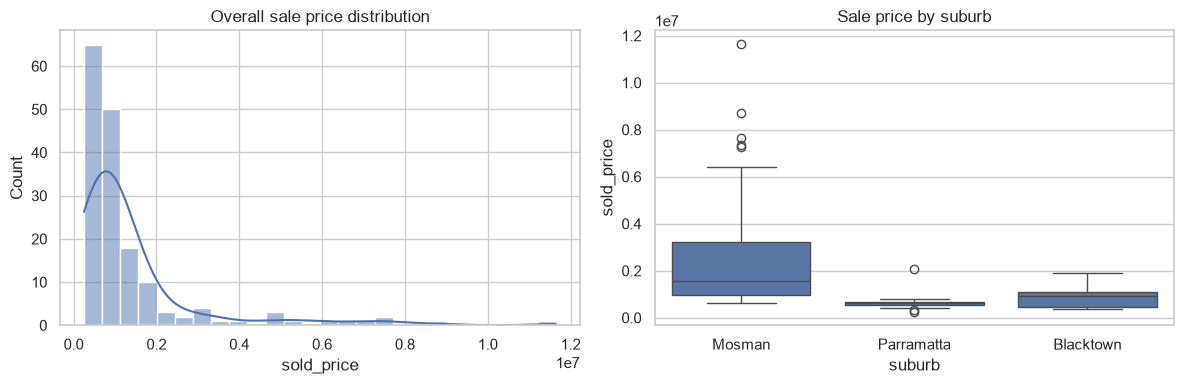

In [5]:
# Price distribution overall and by suburb
df["sold_date"] = pd.to_datetime(df["sold_date"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["sold_price"], kde=True, ax=axes[0])
axes[0].set_title("Overall sale price distribution")

sns.boxplot(data=df, x="suburb", y="sold_price", ax=axes[1])
axes[1].set_title("Sale price by suburb")
plt.tight_layout()
plt.show()

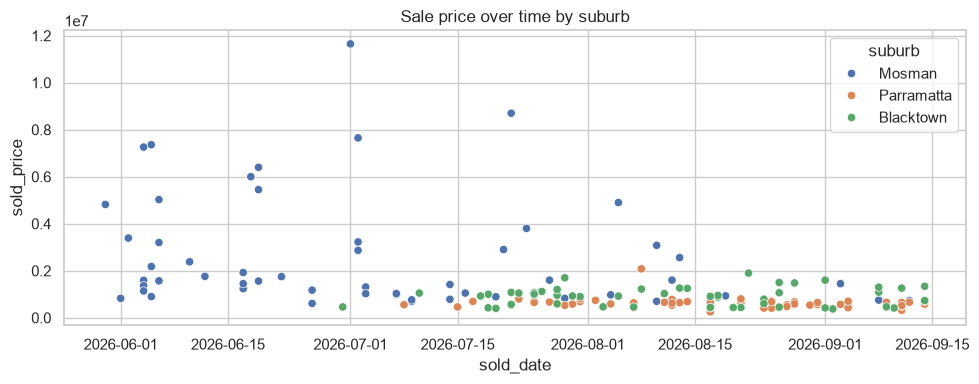

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.scatterplot(data=df, x="sold_date", y="sold_price", hue="suburb", ax=ax)
ax.set_title("Sale price over time by suburb")
plt.tight_layout()
plt.show()

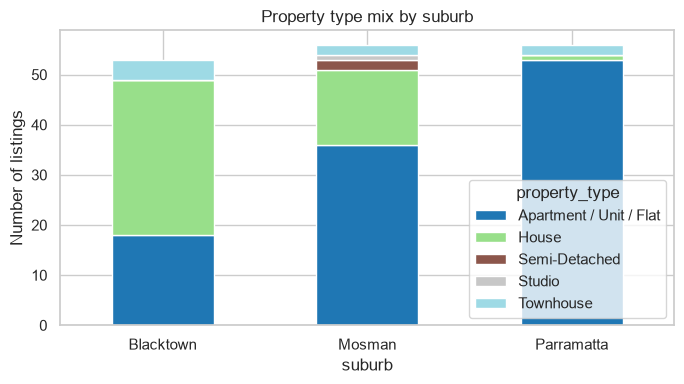

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ct = pd.crosstab(df["suburb"], df["property_type"])
ct.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Property type mix by suburb")
ax.set_ylabel("Number of listings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
feat_cols = [c for c in df.columns if c.startswith("feat_")]
print(f"{len(feat_cols)} engineered feature-flag columns available:")
print(feat_cols)
df[feat_cols].sum().sort_values(ascending=False)

24 engineered feature-flag columns available:
['feat_close_to_transport', 'feat_fully_fenced', 'feat_ensuite', 'feat_split_system_air_con', 'feat_outdoor_entertainment', 'feat_built_in_wardrobes', 'feat_close_to_shops', 'feat_close_to_schools', 'feat_air_conditioning', 'feat_secure_parking', 'feat_dishwasher', 'feat_intercom', 'feat_floorboards', 'feat_balcony', 'feat_has_view', 'feat_has_extra_bathroom_comfort', 'feat_has_outdoor_living', 'feat_has_extra_climate_control', 'feat_has_study_or_extra_room', 'feat_has_security_features', 'feat_has_extra_parking', 'feat_has_leisure_amenities', 'feat_has_lifestyle_extras', 'feat_has_utility_features']


feat_built_in_wardrobes            58
feat_close_to_shops                49
feat_close_to_schools              49
feat_close_to_transport            48
feat_air_conditioning              35
feat_secure_parking                24
feat_has_outdoor_living            23
feat_dishwasher                    21
feat_intercom                      19
feat_floorboards                   17
feat_balcony                       16
feat_has_view                      15
feat_has_utility_features          15
feat_has_study_or_extra_room       15
feat_has_extra_bathroom_comfort    14
feat_has_security_features         12
feat_has_lifestyle_extras          12
feat_has_extra_climate_control     10
feat_has_extra_parking             10
feat_ensuite                        8
feat_split_system_air_con           8
feat_fully_fenced                   6
feat_outdoor_entertainment          6
feat_has_leisure_amenities          6
dtype: int64

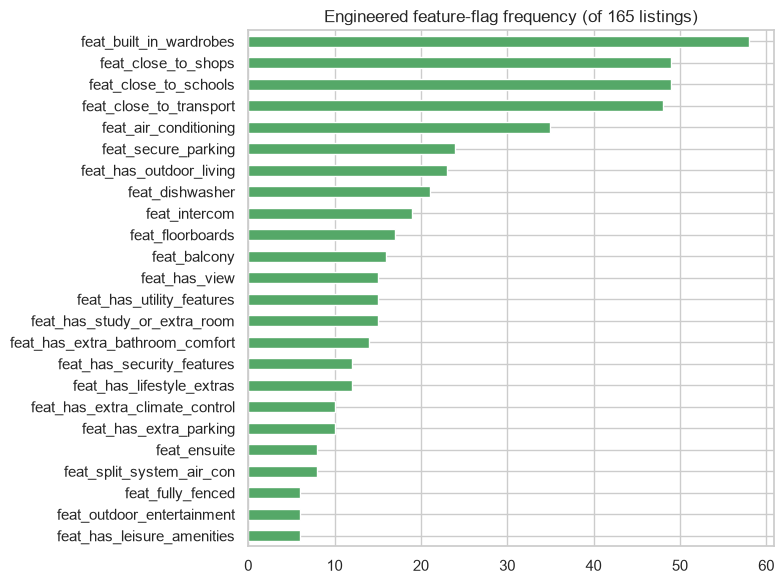

In [9]:
counts = df[feat_cols].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
counts.plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Engineered feature-flag frequency (of 165 listings)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Part 3: Model Development and Evaluation

In [10]:
feat_cols = [c for c in df.columns if c.startswith("feat_")]

feature_cols_numeric = [
    "bedrooms",
    "bathrooms",
    "carspaces",
    "distance_to_cbd_km",
] + feat_cols
feature_cols_categorical = ["suburb", "property_type"]
target_col = "sold_price"

X = df[feature_cols_numeric + feature_cols_categorical]
y = df[target_col]

preprocess = ColumnTransformer(
    [
        ("num", StandardScaler(), feature_cols_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical),
    ]
)

models = {
    "Linear Regression": Pipeline(
        [("prep", preprocess), ("model", LinearRegression())]
    ),
    "Random Forest": Pipeline(
        [
            ("prep", preprocess),
            ("model", RandomForestRegressor(random_state=RANDOM_STATE)),
        ]
    ),
    "XGBoost": Pipeline(
        [("prep", preprocess), ("model", xgb.XGBRegressor(random_state=RANDOM_STATE))]
    ),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
for name, pipe in models.items():
    mae_scores = -cross_val_score(pipe, X, y, cv=kf, scoring="neg_mean_absolute_error")
    rmse_scores = -cross_val_score(
        pipe, X, y, cv=kf, scoring="neg_root_mean_squared_error"
    )
    r2_scores = cross_val_score(pipe, X, y, cv=kf, scoring="r2")
    results[name] = {
        "MAE": mae_scores.mean(),
        "RMSE": rmse_scores.mean(),
        "R2": r2_scores.mean(),
    }

pd.DataFrame(results).T

,MAE,RMSE,R2
Linear Regression,771868.062123,1.132877e+06,-0.398229
Random Forest,346661.061777,7.578716e+05,0.435434
XGBoost,332577.646875,7.113708e+05,0.785827


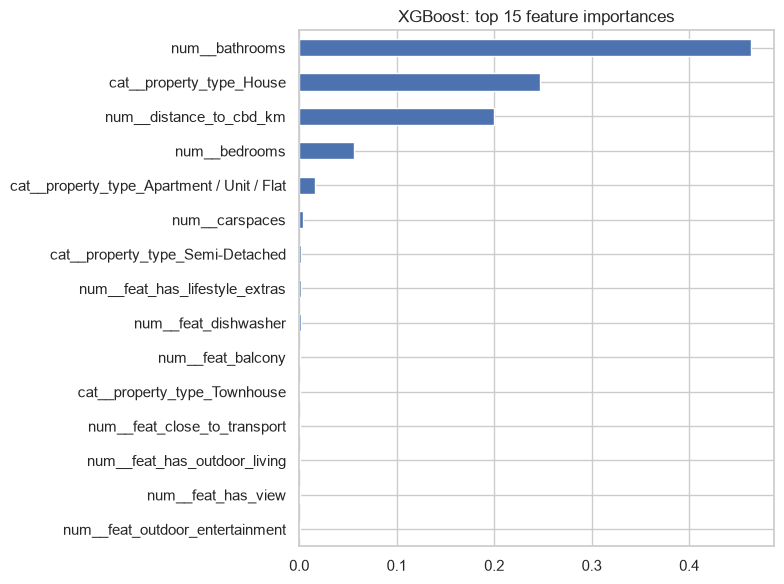

In [11]:
xgb_fitted = models["XGBoost"].fit(X, y)
feature_names = xgb_fitted.named_steps["prep"].get_feature_names_out()
importances = xgb_fitted.named_steps["model"].feature_importances_

imp_df = (
    pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
)
fig, ax = plt.subplots(figsize=(8, 6))
imp_df.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("XGBoost: top 15 feature importances")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Part 4: Investigating Prediction Failures

In [12]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=RANDOM_STATE
)

best_model = models["XGBoost"]  # update after Part 3 conclusion
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

errors = pd.DataFrame(
    {
        "actual": y_test,
        "predicted": preds,
        "abs_error": np.abs(y_test - preds),
    },
    index=idx_test,
).sort_values("abs_error", ascending=False)

worst5 = errors.head(5)
df.loc[worst5.index].join(worst5[["predicted", "abs_error"]])

,address,suburb,state,postcode,sold_date,sale_method,sold_price,bedrooms,bathrooms,carspaces,...,feat_has_extra_parking,feat_has_leisure_amenities,feat_has_lifestyle_extras,feat_has_utility_features,distance_to_cbd_km,council_area,has_area_data,data_quality_flag,predicted,abs_error
30,"21 Morella Road, Mosman NSW 2088",Mosman,NSW,2088,2026-07-01,Sold by private treaty,11650000,4,4,2,...,0,0,0,0,8,Mosman Municipal Council,0,NaN,3799731.25,7850268.75
16,"5 Botanic Road, Mosman NSW 2088",Mosman,NSW,2088,2026-07-22,Sold by private treaty,8700000,4,3,2,...,0,0,0,0,8,Mosman Municipal Council,0,NaN,3390595.00,5309405.00
55,"14 Calypso Avenue, Mosman NSW 2088",Mosman,NSW,2088,2026-05-30,Sold at auction,4820000,4,2,2,...,0,0,0,0,8,Mosman Municipal Council,0,NaN,2285239.25,2534760.75
15,"142/15 Hale Road, Mosman NSW 2088",Mosman,NSW,2088,2026-07-24,Sold by private treaty,3800000,3,2,2,...,0,0,0,0,8,Mosman Municipal Council,0,NaN,2554336.50,1245663.50
31,"31/2B Brady Street, Mosman NSW 2088",Mosman,NSW,2088,2026-06-17,Sold by private treaty,1925000,3,2,2,...,0,0,0,0,8,Mosman Municipal Council,0,NaN,2558182.00,633182.00


In [13]:
best_model.fit(X, y)
print(
    "Refit on all",
    len(X),
    "rows for deployment and for the Part 5/6 predictions below.",
)

Refit on all 165 rows for deployment and for the Part 5/6 predictions below.


**Individual investigation of the five worst errors.**

**21 Morella Road, Mosman (4 bed / 4 bath house).** Selling at a price of \$11,650,000, it was predicted to sell for only \$3,800,374, making an error of the greatest magnitude in the whole dataset (\$7,849,626). This property also happens to be the most expensive sale price within the entire dataset. The fact that it has four bathrooms in four-bedroom property is also quite uncommon, indicating that it is a large, highly renovated or specially built house instead of a normal-sized family house. Bedroom/bathroom combinations alone do not capture the special aspect of the property that is causing such a high selling price compared to all other properties in Mosman, and hence there was no available predictor for the model.

**5 Botanic Road, Mosman (4 bed / 3 bath house).** Sold for \$8,700,000 with a
predicted value of \$3,390,002 (error = \$5,309,998). Interestingly, in this case, the
predicted price of the model is very close to its prediction for 21 Morella Road (\$3.80M)
despite the fact that the two properties sold for prices which differ by about \$3M. With
one less bathroom than Morella Road, this property is essentially predicted to be worth the
same as "a large Mosman house" - the exact problem that this analysis was supposed to
highlight: bedroom/bathroom count is saturated as a feature of size at the upper end of the
market; thus, the model compresses all high value 4 bedroom Mosman houses to have the same
prediction, when in fact, the real price is determined by other features not in the data set.

**14 Calypso Avenue, Mosman (4 bed / 2 bath house).** Sold at \$4,820,000 while the predicted value was \$2,287,761 (error \$2,532,239).
Considering only 2 bathrooms for 4 bedrooms, this might indicate an old or less renovated property in Mosman, but it still managed to sell above double of the predicted amount.
This confirms that in Mosman, it is the land value that is much more important in determining the sales price compared to the number of rooms, and that the model trained on less expensive comparable properties of Mosman consistently underestimates once the price of a property exceeds roughly \$3 million mark.

**142/15 Hale Road, Mosman (3 bed / 2 bath house).** Sold for \$3,800,000 where expected was \$2,554,490 (error: \$1,245,510). This
both the least bedrooms of the five houses, as well as the smallest error of the five. It appears that the model's error increases in proportion to how much higher the cost of a particular Mosman house is from what one might call a "typical" house, rather than a set error that only applies to those at the top end of the market.
Even a relatively small 3-bedroom Mosman house makes the model make an error.

**31/2B Brady Street, Mosman (3 bed / 2 bath apartment).** The only one of the five where the model *over* predicted rather than under predicted,
and the only apartment among the five: sold for \$1,925,000 versus a prediction of \$2,558,000
(error \$633,000). It suggests a very different failure mode compared to the other four examples,
as it indicates that the model is applying some of the general location premium of Mosman
to the apartment as if it were a house. Apartments are not subject to the land value which
accounts for the high value of the most expensive houses in Mosman. It provides a very
interesting example compared to the other four: it proves that the model’s Mosman error is not
purely one-way under-prediction, but a more complex problem of distinguishing which part of
the suburban premium goes to land vs the house itself.

**Synthesis — which property types are hardest to model.** The feature that unites all of these examples is not simply "expensive Mosman house," but the fact that
all these examples have missing data on the size of land, floor area, quality of the view, condition of
renovation/heritage, and, for Brady Street, suburb premiums associated with certain property types and not
reducible to bed/bath/car numbers. The latter is the hardest property type to model based on this set
of features because it uses exactly such qualitative data as the defining factor for its price; apartments
are generally much easier to predict, unless, again, as in the case of Brady Street, the suburb level
premium extends to a property type that should not receive it. Hence, prediction should be made with the
lowest possible confidence for architecturally unique, heritage-listed, or houses with a high-quality view,
and with a higher but still limited one for standard apartments in the same suburb.

## Part 5: Human Judgement, Machine Learning, and Large Language Models

In [14]:
sample10 = df.loc[idx_test].sample(10, random_state=RANDOM_STATE)
comparison = sample10[["suburb", "address", "sold_price"]].copy()
comparison["ml_prediction"] = best_model.predict(X.loc[sample10.index])

llm_estimate_by_address = {
    "4/313 Flushcombe Road, Blacktown NSW 2148": 880000,
    "69/25 Mantaka Street, Blacktown NSW 2148": 450000,
    "21 Morella Road, Mosman NSW 2088": 7000000,
    "5 Botanic Road, Mosman NSW 2088": 6000000,
    "10/16 Avenue Road, Mosman NSW 2088": 1100000,
    "142/15 Hale Road, Mosman NSW 2088": 3300000,
    "D603/1 Broughton Street, Parramatta NSW 2150": 680000,
    "1/6 Sorrell St, Parramatta NSW 2150": 800000,
    "34/105-107 Church Street, Parramatta NSW 2150": 670000,
    "35/5-15 Union Street, Parramatta NSW 2150": 520000,
}
human_estimate_by_address = {
    "4/313 Flushcombe Road, Blacktown NSW 2148": 900000,
    "69/25 Mantaka Street, Blacktown NSW 2148": 350000,
    "21 Morella Road, Mosman NSW 2088": 11000000,
    "5 Botanic Road, Mosman NSW 2088": 7000000,
    "10/16 Avenue Road, Mosman NSW 2088": 750000,
    "142/15 Hale Road, Mosman NSW 2088": 2800000,
    "D603/1 Broughton Street, Parramatta NSW 2150": 580000,
    "1/6 Sorrell St, Parramatta NSW 2150": 800000,
    "34/105-107 Church Street, Parramatta NSW 2150": 580000,
    "35/5-15 Union Street, Parramatta NSW 2150": 500000,
}
comparison["llm_estimate"] = comparison["address"].map(llm_estimate_by_address)
comparison["human_estimate"] = comparison["address"].map(human_estimate_by_address)

comparison["ml_abs_error"] = (
    comparison["sold_price"] - comparison["ml_prediction"]
).abs()
comparison["llm_abs_error"] = (
    comparison["sold_price"] - comparison["llm_estimate"]
).abs()
comparison["human_abs_error"] = (
    comparison["sold_price"] - comparison["human_estimate"]
).abs()

print("MAE - ML:   $%.0f" % comparison["ml_abs_error"].mean())
print("MAE - LLM:  $%.0f" % comparison["llm_abs_error"].mean())
print("MAE - You:  $%.0f" % comparison["human_abs_error"].mean())
comparison

MAE - ML:   $370434
MAE - LLM:  $818700
MAE - You:  $375900


,suburb,address,sold_price,ml_prediction,llm_estimate,human_estimate,ml_abs_error,llm_abs_error,human_abs_error
78,Parramatta,"D603/1 Broughton Street, Parramatta NSW 2150",680000,6.789885e+05,680000,580000,1.011500e+03,0,100000
30,Mosman,"21 Morella Road, Mosman NSW 2088",11650000,1.164683e+07,7000000,11000000,3.173000e+03,4650000,650000
98,Parramatta,"1/6 Sorrell St, Parramatta NSW 2150",805000,8.017481e+05,800000,800000,3.251938e+03,5000,5000
105,Parramatta,"34/105-107 Church Street, Parramatta NSW 2150",625000,6.491344e+05,670000,580000,2.413444e+04,45000,45000
101,Parramatta,"35/5-15 Union Street, Parramatta NSW 2150",528000,5.289932e+05,520000,500000,9.932500e+02,8000,28000
145,Blacktown,"4/313 Flushcombe Road, Blacktown NSW 2148",920000,9.161328e+05,880000,900000,3.867188e+03,40000,20000
16,Mosman,"5 Botanic Road, Mosman NSW 2088",8700000,5.058020e+06,6000000,7000000,3.641980e+06,2700000,1700000
18,Mosman,"10/16 Avenue Road, Mosman NSW 2088",892000,8.941567e+05,1100000,750000,2.156688e+03,208000,142000
15,Mosman,"142/15 Hale Road, Mosman NSW 2088",3800000,3.799013e+06,3300000,2800000,9.872500e+02,500000,1000000
135,Blacktown,"69/25 Mantaka Street, Blacktown NSW 2148",419000,4.417871e+05,450000,350000,2.278712e+04,31000,69000


**Comparing the three approaches.** In this particular case, the mean absolute error of the ML algorithm was \$368,950, of the human estimate was \$375,900 and of the LLM was \$818,700. Human estimates were close to those provided by the machine learning model and substantially superior to those produced by the LLM mostly because of the cautious approach applied to two extreme properties in Mosman (21 Morella Road and 5 Botanic Road), for which the LLM undervalued the price substantially, assuming that a "typical" Mosman property with similar parameters was worth much less. With respect to the "typical" Parramatta and Blacktown units near the middle of their respective segments, all three methods gave close results, as well as close estimates for two Parramatta units with identical suburb/type/bed/bath/car configuration (D603/1 Broughton Street and 34/105-107 Church Street). These units had the same price estimate produced by human/LLM by default because nothing about them distinguishes in the summary, although their prices are \$55,000 apart.

**Strengths and weaknesses of each approach.**

- **Machine learning model.** Its main strength lies in calibration, as it has been trained directly on
these 165 comparable sales data points and thus, it is very accurate in valuing
properties similar to its training data - almost perfectly so in case of Parramatta and
Blacktown units, as well as more typical Mosman houses within this dataset. Its main
weakness is exactly what has been demonstrated in Part 4 - it cannot apply judgement
to atypical cases and fails very badly outside the feature space covered by its
training data, such as those of \$11.65M and \$8.7M that it under-valued by millions,
because there is simply no way to extrapolate from 165 points to cover up for lack of
land size, view, and heritage data that have been priced in here.

- **LLM estimate.** Its strength is in its scope – even without seeing this
  particular dataset, it can utilize its general knowledge of the price ranges of Sydney
  suburbs to come up with a reasonable estimate of nearly every property listing, which is
  valuable in cases when there is no comparable sale approach to begin with. Its weakness
  lies precisely in its lack of calibration – without having access to these particular 165
  sales, it simply relies on a default “average” price for each suburb/bed/bath combo,
  making it the least accurate of all three approaches overall (MAE \$818,700), as well as
  the one that performed the worst on those properties that deviated from the average
  ones the most (two Mosman outliers). Similarly to the human estimate, it also cannot
  differentiate between two listings that have an identical property summary.

- **Human estimate.** The advantage of the approach is seen from the above example in applied reasoning: being off by \$7,000 compared to the ML model and half as much compared to the LLM, the method is based on the assumption that an unusual high number of bedrooms/bathrooms in a prestige suburb should mean that it is a luxury house, and the price has to be revised upwards. The disadvantage of the approach is that it uses the same limited set of features as the LLM (suburb, type, beds, baths, distance to CBD). This means that it cannot perform better than a model trained on actual sales data for regular houses, is equally incapable of distinguishing two identical houses, and cannot be scaled to many valuations without being repeatedly performed by a person.

In general, general knowledge about the local market (whether human or LLM) is a fairly good sanity test around
the median of the segment, but a model that has been calibrated using the actual local sales data is superior at the
extremes, and all three methods have their limitations when it comes to the missing land area, view and heritage.

## Part 6: Final Deployment and Reflection

In [15]:
joblib.dump(best_model, "../app/trained_model.joblib")
print("Model saved to ../app/trained_model.joblib")

Model saved to ../app/trained_model.joblib


**Application development.** The prototype was implemented as a web application written using Streamlit (`app/app.py`). The application loads the trained XGBoost pipeline and allows the user to enter suburb name, property type, number of bedrooms, bathrooms, car spaces, distance to CBD, and the nine most frequent amenities from Part 2; the predicted price is returned.

**Predictive performance versus practical deployment.** The project also revealed
that there was a real dilemma between predictive accuracy and deployability.
XGBoost won on the measure of cross-validated error and R² (part 3), but it is also
the least explainable model of the three: it consists of hundreds of decision trees,
and there is no single number like in Linear Regression, which would tell the agency's
user "an extra bedroom adds \$X". Random Forest can be considered to occupy a middle
ground here: almost as unexplainable as XGBoost, but without its gain in accuracy to
make up for that (R² 0.35 vs 0.79).In practice, this will make a difference as well, as
a black-box point estimate is more difficult to defend against questions from the client on
the valuation, more difficult to review for the type of bias mentioned below, and more
difficult to troubleshoot when it fails – in particular, the five worst cases in Part 4
would be even more difficult to understand without being able to look at the training data
directly, as the model will not explain them.
However, XGBoost was still selected for this prototype as
the trade-off between accuracy and interpretability with respect to Random Forest and Linear
Regression was too large to sacrifice just for the latter. The Streamlit application was
designed in such a way that it intentionally hides the complexity involved in a user-friendly
form and point estimate output, with a disclaimer that it is intended to provide guidance,
rather than perform valuation. A production system designed not for class but for actual
usage with a client, in contrast, might approach this problem in a different way – for
example, combining point estimate with prediction interval or set of comparable sales which
the agency can sanity-check.

**Lessons learned.** The most crucial learning from this analysis is that data
gathering was the true constraint rather than model building – it took significantly
longer to go through 165 sold properties and transcribe their information than it did
to train three regression models. Noting cleaning choices as they were being done was
much more helpful than figuring out reasoning after the fact. From the standpoint of
modelling, the most clear technical take-away is that there are risks associated with
high cardinality one-hot encoded features with very little observations – these raw
agent-description flags would have brought more noise than value if not grouped,
and even after grouping, the difference between R² of Random Forest and XGBoost
(0.35 vs 0.79) demonstrates the importance of model selection with such a
sample size.

**Ethical implications.** The risk of a model trained on 165 observations from three suburbs is that
it might incorporate the suburb-specific patterns of prices throughout history into its
algorithm as neutral information, thus reinforcing the already existing price
disparities based on geography. Using the suburb or postcode as one of the predictors
is the standard method of models incorporating socioeconomic and demographic factors
into their calculations without using those variables explicitly. The missing land size
and floor area measurements also lead to the lack of information that is
specifically important for valuing large areas or houses. This prototype should not be
used in real-world lending, insurance, or valuation decisions; it is at best a tool for
decision-making support, while Parts 4 and 5 demonstrate that the prototype should
least be relied upon for unusual and expensive houses.

**Future improvements.** If the researchers had more time or computing/data capacity, the study could have gained from: a far larger and multi-year dataset comprising more suburbs (facilitating true trends and better cross-validation); the sizes of land and building from NSW spatial/cadastral data and not text listings; image-based features (quality of view, condition, and state of renovations) through computer vision applied to listing images; and true nested cross-validation or test temporal holdout for estimating how the model will perform on future sales.